<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 1</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Introduction to Data Science <br><br>
        <b>Team Members:</b><br>
        • Parsa Saeednia (810102460) <br>
        • Mohammad Hossein Mazaheri (810102585) <br>
        • Mohammad Reza Pirhadi (810102423)
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 1. It focuses on statistical sampling techniques, specifically comparing Direct Sampling with Langevin Dynamics for a 2D Gaussian distribution. Subsequent sections provide placeholders for Business Intelligence dashboard links and theoretical data visualization analyses.
</div>

## Table of Contents
1. [Task 1: Sampling and Inference](#task1)
2. [Task 2: Tableau Dashboard Storytelling](#task2)
3. [Task 3: Power BI Dashboard Improvement](#task3)
4. [Task 4: Data Visualization Principles](#task4)

<a id="task1"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px;">Task 1: Sampling and Inference</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we generate samples from a 2D Gaussian distribution using two distinct methods. The visual outputs generated here will be exported to the final LaTeX report.
</div>

### 1.1 Guassian Distribution

#### 1.1.1 Setup and Parameters

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import os

np.random.seed(42)
mu = np.array([0.0, 0.0])

cov = np.eye(2) 

print(f"Mean (\u03bc):\n{mu}")
print(f"Covariance Matrix (\u03a3):\n{cov}")

Mean (μ):
[0. 0.]
Covariance Matrix (Σ):
[[1. 0.]
 [0. 1.]]


#### 1.1.2 Visualization

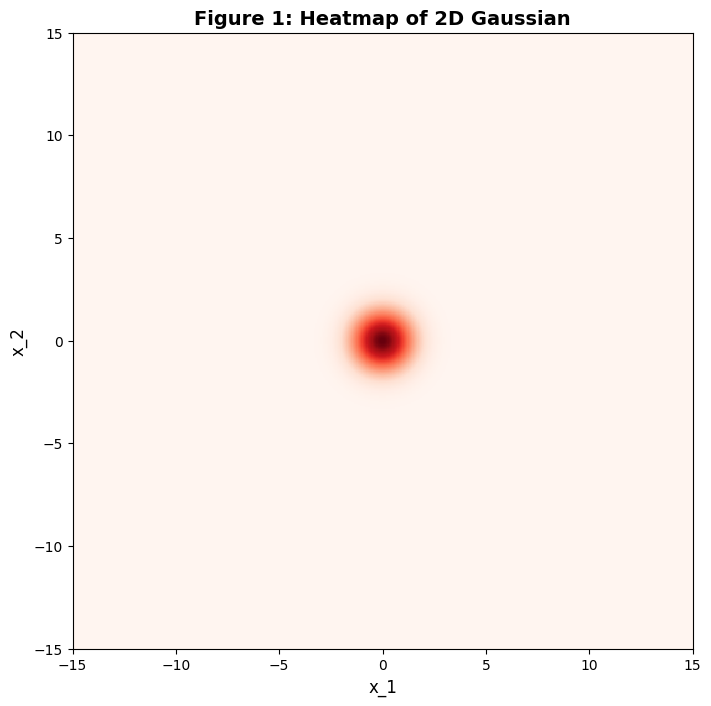

In [69]:
x = np.linspace(-15, 15, 500)
y = np.linspace(-15, 15, 500)
X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))

rv = multivariate_normal(mu, cov)
Z = rv.pdf(pos)

plt.figure(figsize=(8, 8))

plt.pcolormesh(X, Y, Z, shading='auto', cmap='Reds')

plt.xlabel('x_1', fontsize=12)
plt.ylabel('x_2', fontsize=12)
plt.title('Figure 1: Heatmap of 2D Gaussian', fontsize=14, fontweight='bold')
plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.savefig('latex/assets/images/figure1_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

### 1.2 Sampling

#### 1.2.1 Langevin Simulation

In [70]:
T = 500           
epsilon = 0.05       
N = 1000

x_t = np.random.uniform(-5, 5, size=(N, 2))
trajectories = np.zeros((T, 10, 2))

def langevin_score_function(x):
    return -x

for t in range(T):
    trajectories[t] = x_t[:10]
    score = langevin_score_function(x_t)
    
    z_t = np.random.randn(N, 2)
    x_t = x_t + epsilon * score + np.sqrt(2 * epsilon) * z_t

langevin_samples = x_t
print("Langevin Dynamics simulation complete!")

Langevin Dynamics simulation complete!


#### 1.2.2 Plotting the Trajectories

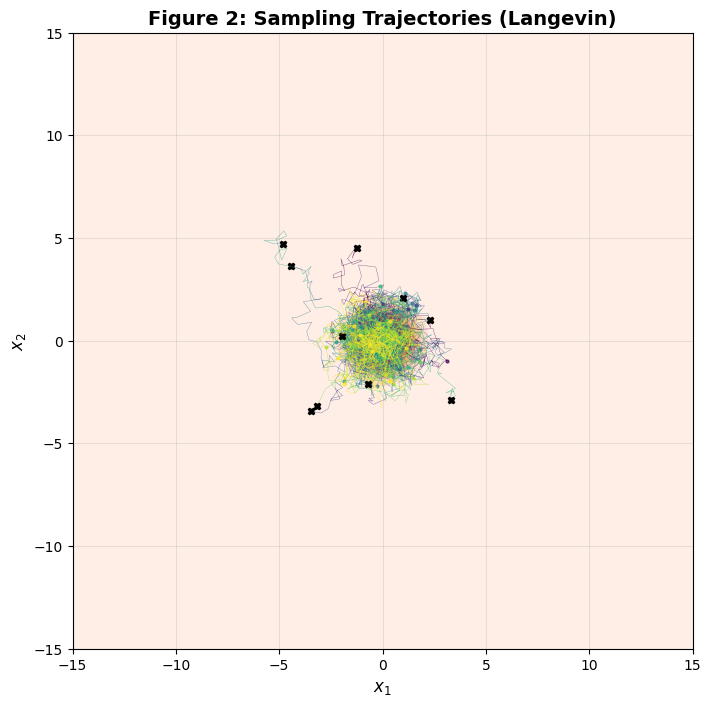

In [71]:
plt.figure(figsize=(8, 8))

x_grid, y_grid = np.mgrid[-15:15:100j, -15:15:100j]
pos = np.dstack((x_grid, y_grid))
rv = multivariate_normal(mu, cov)
plt.contourf(x_grid, y_grid, rv.pdf(pos), levels=10, cmap='Reds', alpha=1)

colors = plt.cm.viridis(np.linspace(0, 1, 10))
for i in range(10):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], 
             color=colors[i], alpha=0.7, linewidth=0.3, marker='o', markersize=2, markevery=50)
    
    plt.plot(trajectories[0, i, 0], trajectories[0, i, 1], 'kX', markersize=5)

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Figure 2: Sampling Trajectories (Langevin)', fontsize=14, fontweight='bold')
plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.grid(True, alpha=0.3)

plt.savefig('latex/assets/images/figure2_langevin_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

#### 1.2.3 Direct Sampling & Final Scatter Plots

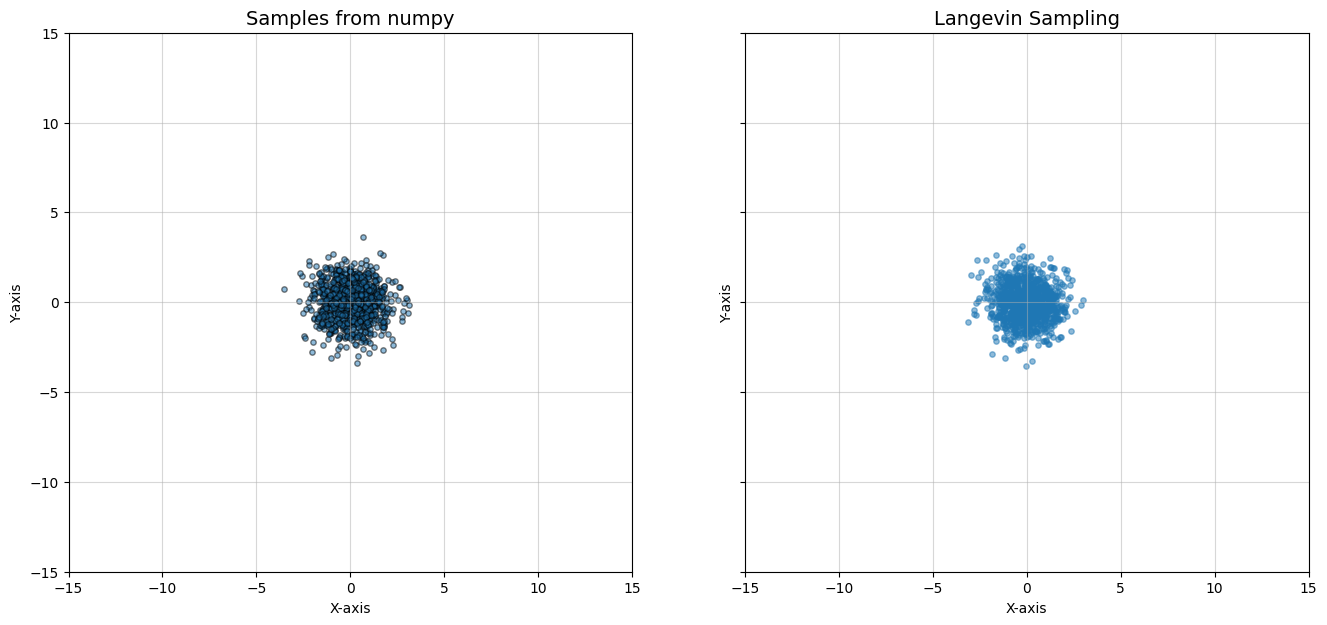

In [72]:
direct_samples = np.random.multivariate_normal(mu, cov, N)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

axes[0].scatter(direct_samples[:, 0], direct_samples[:, 1], alpha=0.5, s=15, edgecolors='k')
axes[0].set_title('Samples from numpy', fontsize=14)
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')
axes[0].grid(True, alpha=0.5)

axes[1].scatter(langevin_samples[:, 0], langevin_samples[:, 1], alpha=0.5, s=15, color='tab:blue')
axes[1].set_title('Langevin Sampling', fontsize=14)
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')
axes[1].grid(True, alpha=0.5)

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.savefig('latex/assets/images/figure3_comparing_samples.png', dpi=300, bbox_inches='tight')
plt.show()

#### 1.2.4 Plotting Average Distance

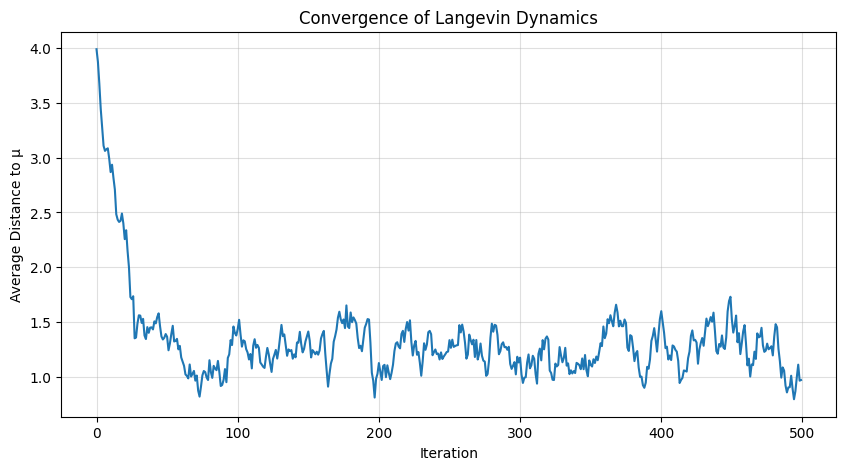

In [73]:
distances = np.linalg.norm(trajectories - mu, axis=2)
mean_distances = np.mean(distances, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(mean_distances, color='tab:blue')
plt.xlabel('Iteration')
plt.ylabel(f'Average Distance to \u03bc')
plt.title('Convergence of Langevin Dynamics')
plt.grid(True, alpha=0.4)
plt.savefig('latex/assets/images/figure4_convergence_of_langevin_samples.png', dpi=300, bbox_inches='tight')
plt.show()

#### 1.3 Inference from Samples

In [74]:
true_mu = np.array([0.0, 0.0])
true_var = np.array([1.0, 1.0])

def calculate_inference(samples, name):
    mean_est = np.mean(samples, axis=0)
    var_est = np.var(samples, axis=0)
    
    mean_err = np.abs(mean_est - true_mu)
    var_err = np.abs(var_est - true_var)
    
    print(f"--- {name} ---")
    print(f"Estimated Mean (x1, x2): [{mean_est[0]:.4f}, {mean_est[1]:.4f}]")
    print(f"Estimated Var  (x1, x2): [{var_est[0]:.4f}, {var_est[1]:.4f}]")
    print(f"Absolute Mean Error    : [{mean_err[0]:.4f}, {mean_err[1]:.4f}]")
    print(f"Absolute Var Error     : [{var_err[0]:.4f}, {var_err[1]:.4f}]\n")

calculate_inference(direct_samples, "NumPy Direct Sampling")
calculate_inference(langevin_samples, "Langevin Dynamics")

--- NumPy Direct Sampling ---
Estimated Mean (x1, x2): [0.0548, 0.0109]
Estimated Var  (x1, x2): [1.0085, 1.0462]
Absolute Mean Error    : [0.0548, 0.0109]
Absolute Var Error     : [0.0085, 0.0462]

--- Langevin Dynamics ---
Estimated Mean (x1, x2): [-0.0582, -0.0358]
Estimated Var  (x1, x2): [0.9567, 0.9897]
Absolute Mean Error    : [0.0582, 0.0358]
Absolute Var Error     : [0.0433, 0.0103]



#### 1.4 Comparing Sampling Methods

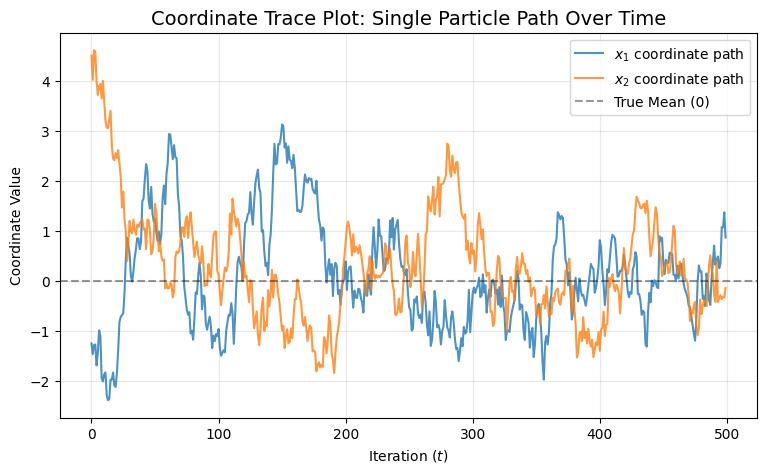

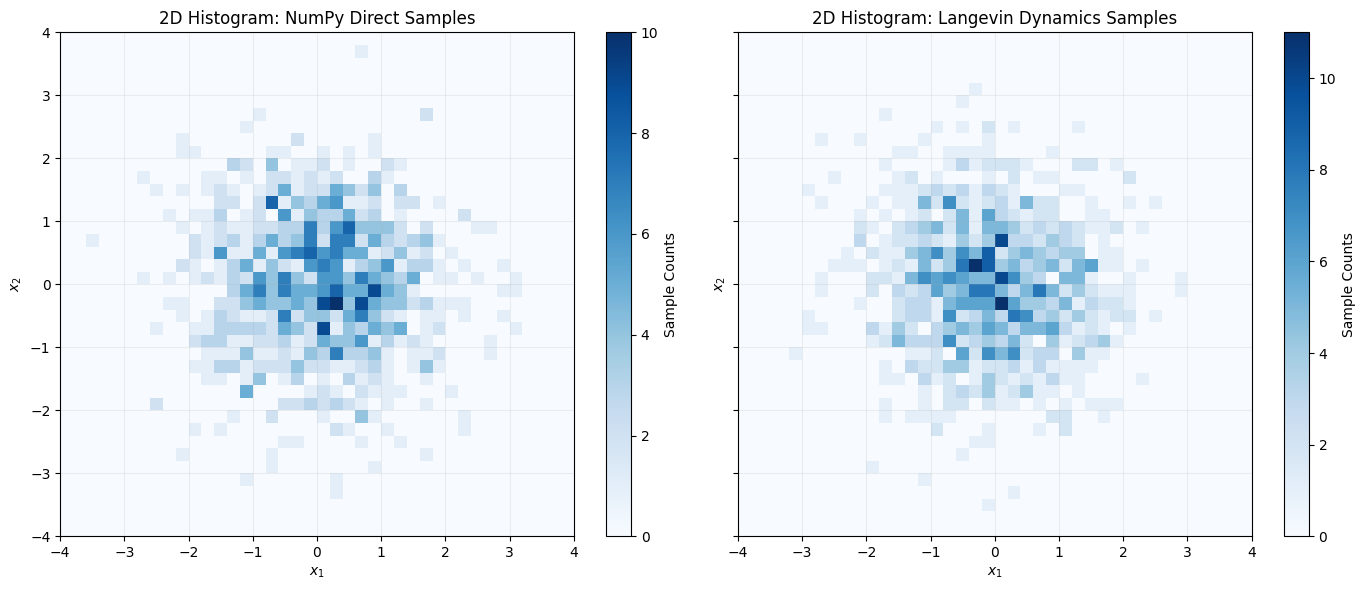

In [76]:
plt.figure(figsize=(9, 5))
plt.plot(range(T), trajectories[:, 0, 0], label='$x_1$ coordinate path', color='tab:blue', alpha=0.8)
plt.plot(range(T), trajectories[:, 0, 1], label='$x_2$ coordinate path', color='tab:orange', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, label='True Mean (0)')
plt.title('Coordinate Trace Plot: Single Particle Path Over Time', fontsize=14)
plt.xlabel('Iteration ($t$)')
plt.ylabel('Coordinate Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('latex/assets/images/figure5_coordinate_trace.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

h1 = axes[0].hist2d(direct_samples[:, 0], direct_samples[:, 1], bins=40, range=[[-4, 4], [-4, 4]], cmap='Blues')
axes[0].set_title('2D Histogram: NumPy Direct Samples', fontsize=12)
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].grid(True, alpha=0.2)
fig.colorbar(h1[3], ax=axes[0], label='Sample Counts')

h2 = axes[1].hist2d(langevin_samples[:, 0], langevin_samples[:, 1], bins=40, range=[[-4, 4], [-4, 4]], cmap='Blues')
axes[1].set_title('2D Histogram: Langevin Dynamics Samples', fontsize=12)
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].grid(True, alpha=0.2)
fig.colorbar(h2[3], ax=axes[1], label='Sample Counts')

plt.tight_layout()
plt.savefig('latex/assets/images/figure6_histograms_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.3 Comparative Analysis
<div style="background-color: #f0fff4; padding: 15px; border-radius: 8px; border: 1px solid #c6f6d5; color: #276749;">
    <strong>📝 Observation Notes:</strong> <br>
    <i>(Double-click this cell to add your notes on convergence, distribution spread, and the computational trade-offs between Direct Sampling and Langevin Dynamics.)</i>
</div>

<a id="task2"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">Task 2: Tableau Dashboard Storytelling</h2>

*Note: The implementation for this task is done entirely in Tableau. The final visualizations, KPIs, and data storytelling insights regarding the Global Tuberculosis dataset are documented in the main LaTeX report. Please refer to the `.twbx` file and the LaTeX report*

<a id="task3"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">Task 3: Power BI Dashboard Improvement</h2>

<div style="padding: 15px; border-radius: 8px; background-color: #faf5ff; border: 1px solid #e9d8fd; color: #553c9a;">
    <strong>📊 Financial Dashboard Enhancements:</strong> <br>
    This task involves redesigning a standard financial dashboard to improve the Data-Ink Ratio, introduce advanced financial indicators, and enhance the visual hierarchy.
</div>

*Note: As this requires the Power BI Desktop environment, there is no programmatic code executed here. Please refer to the `.pbix` file and the LaTeX report for the before/after comparisons and design rationale.*

<a id="task4"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">Questions</h2>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>📄 Theoretical Content Notice:</strong> <br>
    The detailed analytical responses, scenarios, and design rationale regarding <b>Labeling (Clarity vs. Clutter)</b> and <b>Cognitive Load (Visual Simplicity & Gestalt Principles)</b> have been fully written and formatted inside the main LaTeX document. Please refer to the generated final project PDF for the complete submission text.
</div>